In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

In [2]:
df = pd.read_csv("crm_churn_dataset.csv")


In [3]:
print(df.head())

   Age  Tenure_Months  Total_Purchases  Avg_Purchase_Amount  Total_Spent  \
0   56             69               61             14064.03    957276.74   
1   46             39               35             39915.98   1290254.05   
2   32             13               48              9081.37    482214.77   
3   60             41               15             45296.50    800333.02   
4   25             57               71             47653.54   4027715.99   

   Support_Tickets  Complaints  Feedback_Score  Last_Purchase_Days_Ago  \
0                0           3            1.60                      27   
1                5           6            3.28                     137   
2               13           8            4.69                      82   
3                3           9            1.71                      36   
4                2           1            2.47                     174   

   Renewal_Count  Gender_enc  Plan_Type_enc  Payment_Method_enc  Location_enc  \
0              4 

In [4]:
print("Rows and Columns:")
print(df.shape)


Rows and Columns:
(8000, 19)


In [5]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Age', 'Tenure_Months', 'Total_Purchases', 'Avg_Purchase_Amount',
       'Total_Spent', 'Support_Tickets', 'Complaints', 'Feedback_Score',
       'Last_Purchase_Days_Ago', 'Renewal_Count', 'Gender_enc',
       'Plan_Type_enc', 'Payment_Method_enc', 'Location_enc', 'CLV',
       'Activity_Freq', 'Complaint_Ratio', 'Inactive_Flag', 'Churn'],
      dtype='object')


In [6]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     8000 non-null   int64  
 1   Tenure_Months           8000 non-null   int64  
 2   Total_Purchases         8000 non-null   int64  
 3   Avg_Purchase_Amount     8000 non-null   float64
 4   Total_Spent             8000 non-null   float64
 5   Support_Tickets         8000 non-null   int64  
 6   Complaints              8000 non-null   int64  
 7   Feedback_Score          8000 non-null   float64
 8   Last_Purchase_Days_Ago  8000 non-null   int64  
 9   Renewal_Count           8000 non-null   int64  
 10  Gender_enc              8000 non-null   int64  
 11  Plan_Type_enc           8000 non-null   int64  
 12  Payment_Method_enc      8000 non-null   int64  
 13  Location_enc            8000 non-null   int64  
 14  CLV               

In [7]:
print(df.isnull().sum())

Age                       0
Tenure_Months             0
Total_Purchases           0
Avg_Purchase_Amount       0
Total_Spent               0
Support_Tickets           0
Complaints                0
Feedback_Score            0
Last_Purchase_Days_Ago    0
Renewal_Count             0
Gender_enc                0
Plan_Type_enc             0
Payment_Method_enc        0
Location_enc              0
CLV                       0
Activity_Freq             0
Complaint_Ratio           0
Inactive_Flag             0
Churn                     0
dtype: int64


In [8]:
print(df.describe())

               Age  Tenure_Months  Total_Purchases  Avg_Purchase_Amount  \
count  8000.000000    8000.000000      8000.000000          8000.000000   
mean     41.111125      35.946250        50.046875         25266.599331   
std      13.492462      20.479405        28.615080         14381.706125   
min      18.000000       1.000000         1.000000           500.460000   
25%      30.000000      18.000000        25.000000         12798.667500   
50%      41.000000      36.000000        50.000000         25102.875000   
75%      53.000000      54.000000        75.000000         37775.625000   
max      64.000000      71.000000        99.000000         49991.200000   

        Total_Spent  Support_Tickets   Complaints  Feedback_Score  \
count  8.000000e+03      8000.000000  8000.000000     8000.000000   
mean   1.258438e+06         6.937250     4.528625        2.999282   
std    1.095590e+06         4.290817     2.861329        1.156320   
min    4.577700e+02         0.000000     0.00000

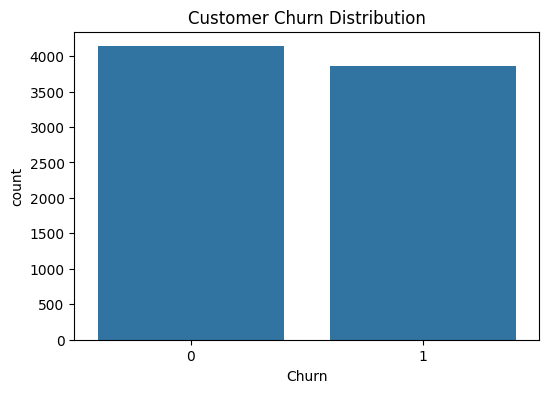

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()

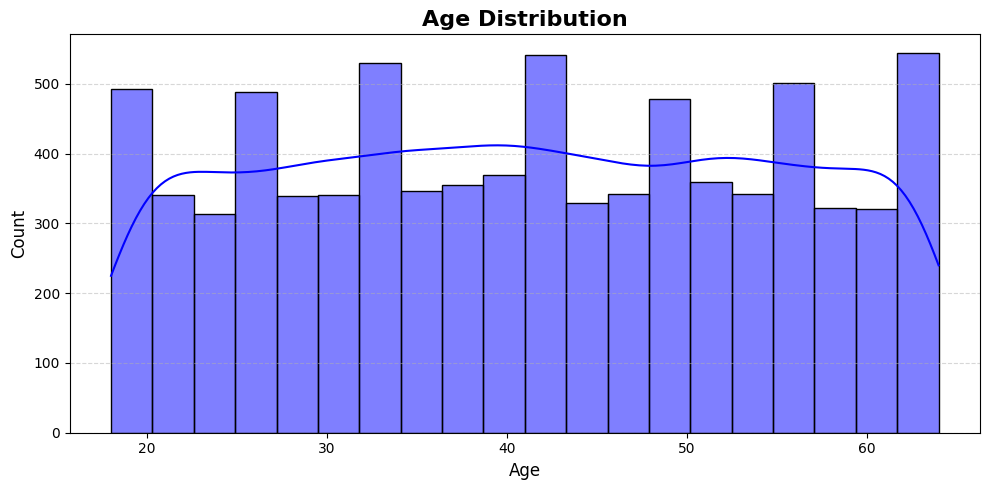

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True,
    color='blue',
    edgecolor='black'
)

plt.title('Age Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

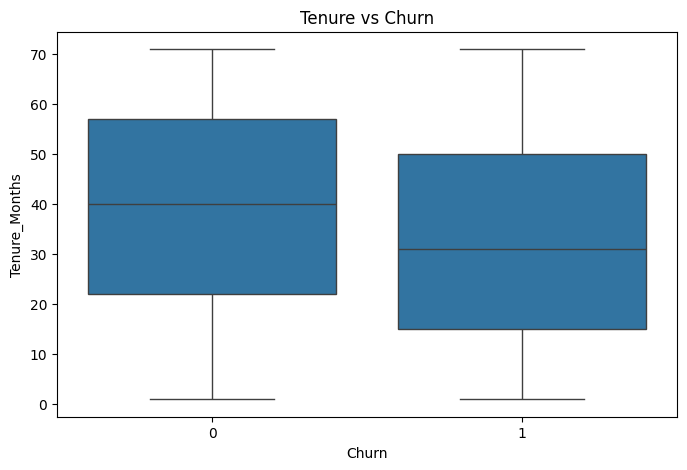

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Tenure_Months', data=df)
plt.title('Tenure vs Churn')
plt.show()

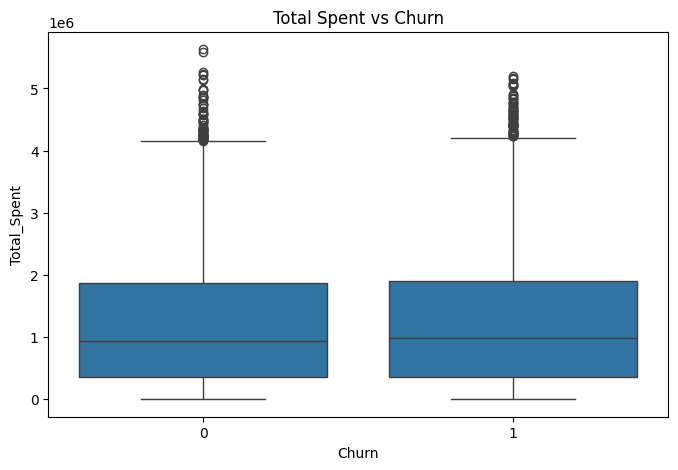

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Total_Spent', data=df)
plt.title('Total Spent vs Churn')
plt.show()

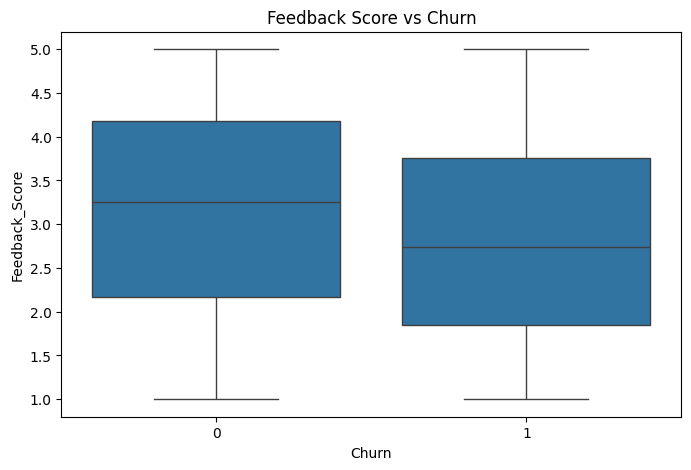

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Feedback_Score', data=df)
plt.title('Feedback Score vs Churn')
plt.show()

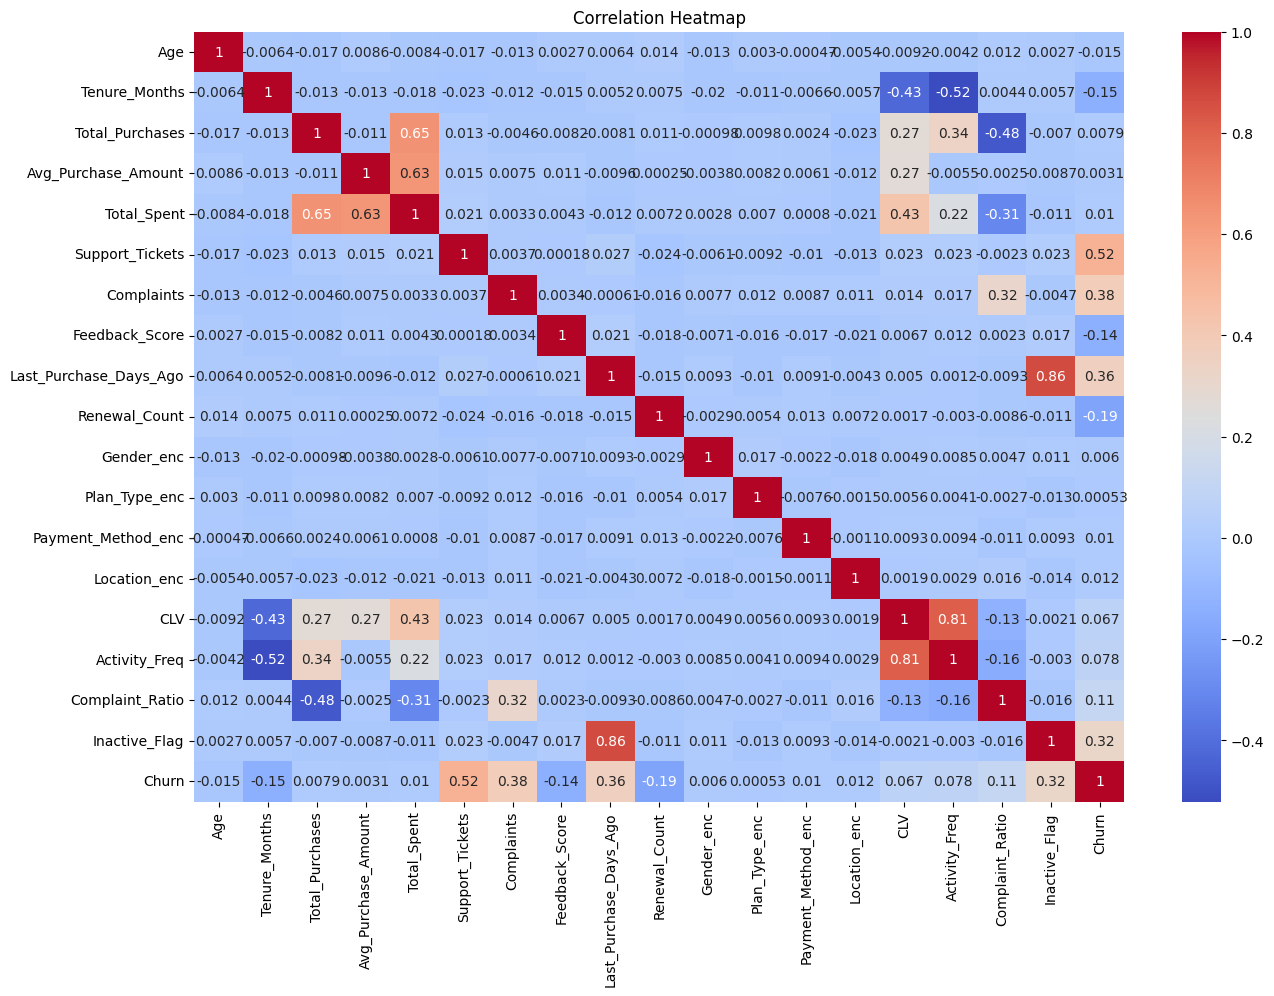

In [14]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Feature Engineering

In [15]:
df['Calculated_CLV'] = df['Avg_Purchase_Amount'] * df['Total_Purchases']

print(df[['Calculated_CLV']].head())

   Calculated_CLV
0       857905.83
1      1397059.30
2       435905.76
3       679447.50
4      3383401.34


In [16]:
df['New_Activity_Freq'] = df['Total_Purchases'] / (df['Tenure_Months'] + 1)

print(df[['New_Activity_Freq']].head())

   New_Activity_Freq
0           0.871429
1           0.875000
2           3.428571
3           0.357143
4           1.224138


In [17]:
X = df.drop('Churn', axis=1)


In [18]:
y = df['Churn']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6400, 20)
(1600, 20)


In [20]:
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

In [21]:

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Building and Comparison

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [23]:
lr_model = LogisticRegression()

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.908125


In [24]:
DT_model = DecisionTreeClassifier(random_state=42)

# Train model
DT_model.fit(X_train, y_train)

# Predictions
y_pred_dt = DT_model.predict(X_test)

# Accuracy
DT_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", DT_accuracy)

Decision Tree Accuracy: 0.823125


In [25]:
RF_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
RF_model.fit(X_train, y_train)

# Predictions
y_pred_rf = RF_model.predict(X_test)

# Accuracy
RF_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", RF_accuracy)

Random Forest Accuracy: 0.865625


In [26]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 0.825625


In [27]:
svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy :", svm_accuracy)

SVM Accuracy : 0.89625


In [28]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'KNN',
    'SVM'
]

accuracies = [
    lr_accuracy,
    DT_accuracy,
    RF_accuracy,
    knn_accuracy,
    svm_accuracy
]

comparison_df = pd.DataFrame({

    'Model': models,
    'Accuracy': accuracies
})

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression  0.908125
1        Decision Tree  0.823125
2        Random Forest  0.865625
3                  KNN  0.825625
4                  SVM  0.896250


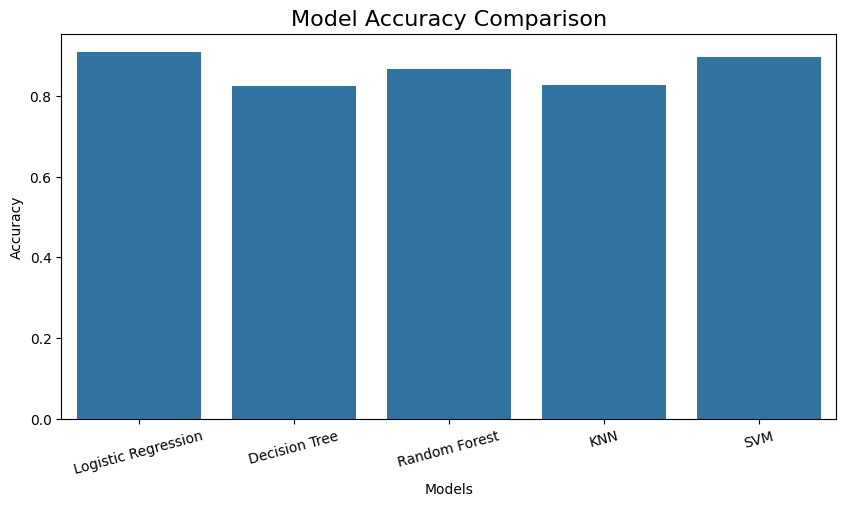

In [29]:
models = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVM'
    ],

    'Accuracy': [
        lr_accuracy,
        DT_accuracy,
        RF_accuracy,
        knn_accuracy,
        svm_accuracy
    ]
})

plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=models
)

plt.title('Model Accuracy Comparison', fontsize=16)

plt.xlabel('Models')

plt.ylabel('Accuracy')

plt.xticks(rotation=15)

plt.show()

In [30]:
print("=" * 60)
print("FINAL MODEL SELECTION")
print("=" * 60)

print("Logistic Regression Accuracy :", lr_accuracy)

print("Decision Tree Accuracy       :", DT_accuracy)

print("Random Forest Accuracy       :", RF_accuracy)

print("KNN Accuracy                 :", knn_accuracy)

print("SVM Accuracy                 :", svm_accuracy)

print("=" * 60)


best_model = lr_model

best_model_name = "Logistic Regression"

best_accuracy = lr_accuracy

best_prediction = y_pred_lr

print(f"Selected Best Model : {best_model_name}")

print(f"Best Accuracy       : {round(best_accuracy*100,2)}%")

FINAL MODEL SELECTION
Logistic Regression Accuracy : 0.908125
Decision Tree Accuracy       : 0.823125
Random Forest Accuracy       : 0.865625
KNN Accuracy                 : 0.825625
SVM Accuracy                 : 0.89625
Selected Best Model : Logistic Regression
Best Accuracy       : 90.81%


In [31]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

cv_mean_f1 = cv_scores.mean()

print("CV Mean F1:", cv_mean_f1)

CV Mean F1: 0.907187666868791


In [32]:
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       858
           1       0.85      0.87      0.86       742

    accuracy                           0.87      1600
   macro avg       0.86      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600



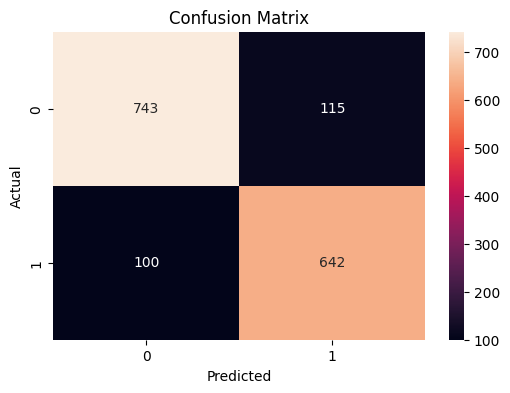

In [33]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [34]:
roc_score = roc_auc_score(y_test, y_pred_rf)

print("ROC AUC Score:", roc_score)

ROC AUC Score: 0.8655982382397476


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.model_selection import cross_val_score

print("\n")

print("=" * 65)
print("             FINAL MODEL EVALUATION SUMMARY")
print("=" * 65)

print(f"Model                : Logistic Regression")

print(f"Dataset              : crm_churn_dataset.csv")

print(f"Total Customers      : {len(df)}")

print(
    f"Churned Customers    : "
    f"{df['Churn'].sum()} "
    f"({round(df['Churn'].mean()*100,2)}%)"
)

print("=" * 65)

print(
    f"Accuracy             : "
    f"{round(lr_accuracy*100,2)}%"
)

print(
    f"Precision            : "
    f"{round(precision_score(y_test, y_pred_lr)*100,2)}%"
)

print(
    f"Recall               : "
    f"{round(recall_score(y_test, y_pred_lr)*100,2)}%"
)

print(
    f"F1 Score             : "
    f"{round(f1_score(y_test, y_pred_lr)*100,2)}%"
)

print(
    f"ROC-AUC              : "
    f"{round(roc_auc_score(y_test, y_pred_lr)*100,2)}%"
)



cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

cv_mean_f1 = cv_scores.mean()

print(
    f"CV Mean F1           : "
    f"{round(cv_mean_f1*100,2)}%"
)

print("=" * 65)


cm = confusion_matrix(y_test, y_pred_lr)

tn, fp, fn, tp = cm.ravel()

print(f"True Positives       : {tp}")

print(
    f"False Negatives      : "
    f"{fn} (Missed Churners)"
)

print(
    f"False Positives      : "
    f"{fp} (Wrong Alerts)"
)

print("=" * 65)


report_df = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC',
        'CV Mean F1'
    ],

    'Value': [

        round(lr_accuracy,4),

        round(
            precision_score(y_test, y_pred_lr),
            4
        ),

        round(
            recall_score(y_test, y_pred_lr),
            4
        ),

        round(
            f1_score(y_test, y_pred_lr),
            4
        ),

        round(
            roc_auc_score(y_test, y_pred_lr),
            4
        ),

        round(
            cv_mean_f1,
            4
        )
    ]
})

report_df.to_csv(
    'model_evaluation_report.csv',
    index=False
)

print(
    "\n Evaluation report saved: "
    "model_evaluation_report.csv"
)



             FINAL MODEL EVALUATION SUMMARY
Model                : Logistic Regression
Dataset              : crm_churn_dataset.csv
Total Customers      : 8000
Churned Customers    : 3863 (48.29%)
Accuracy             : 90.81%
Precision            : 89.93%
Recall               : 90.3%
F1 Score             : 90.11%
ROC-AUC              : 90.78%
CV Mean F1           : 90.72%
True Positives       : 670
False Negatives      : 72 (Missed Churners)
False Positives      : 75 (Wrong Alerts)

 Evaluation report saved: model_evaluation_report.csv


In [36]:
importance = RF_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

                   Feature  Importance
5          Support_Tickets    0.266862
8   Last_Purchase_Days_Ago    0.116250
6               Complaints    0.106262
16         Complaint_Ratio    0.072157
7           Feedback_Score    0.051872
17           Inactive_Flag    0.049612
9            Renewal_Count    0.042797
1            Tenure_Months    0.035420
19       New_Activity_Freq    0.032110
15           Activity_Freq    0.031911
14                     CLV    0.027962
3      Avg_Purchase_Amount    0.026981
0                      Age    0.025883
4              Total_Spent    0.025385
18          Calculated_CLV    0.025107
2          Total_Purchases    0.024253
13            Location_enc    0.013514
11           Plan_Type_enc    0.011823
12      Payment_Method_enc    0.009526
10              Gender_enc    0.004315


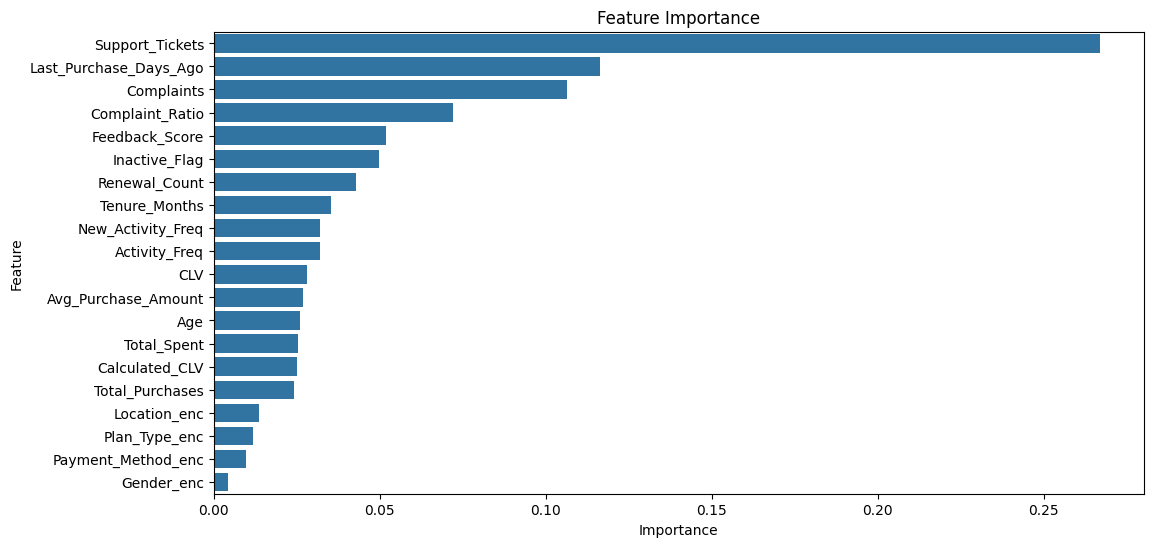

In [37]:
plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.show()

In [38]:
probabilities = RF_model.predict_proba(X_test)

# High risk probability
risk_scores = probabilities[:,1]

risk_category = []

for score in risk_scores:
    
    if score > 0.7:
        risk_category.append('High Risk')
        
    elif score > 0.4:
        risk_category.append('Medium Risk')
        
    else:
        risk_category.append('Low Risk')

risk_df = pd.DataFrame({
    'Risk Score': risk_scores,
    'Risk Category': risk_category
})

print(risk_df.head())

   Risk Score Risk Category
0        0.12      Low Risk
1        0.00      Low Risk
2        0.74     High Risk
3        0.52   Medium Risk
4        0.38      Low Risk


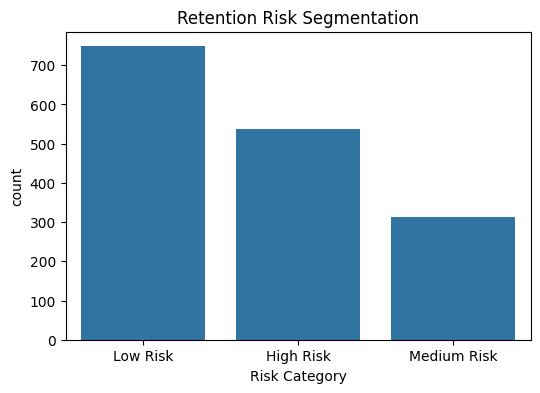

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(x='Risk Category', data=risk_df)
plt.title('Retention Risk Segmentation')
plt.show()

In [40]:
import joblib

joblib.dump(RF_model, 'customer_churn_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully


In [41]:
sample = X_test.iloc[0:1]

prediction = RF_model.predict(sample)

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Stay")

Customer Will Stay


In [42]:
app_code = """
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# =========================================
# Load Trained Model
# =========================================

model = joblib.load('customer_churn_model.pkl')

# =========================================
# Dashboard Title
# =========================================

st.title("Customer Churn Prediction & CRM Analytics Dashboard")

# =========================================
# Project Description
# =========================================

st.write(
    '''
    This AI/ML dashboard predicts customer churn using Machine Learning models.

    The system helps businesses:

    - Identify customers likely to leave
    - Reduce revenue loss
    - Improve customer retention
    - Analyze customer behavior
    - Support data-driven business decisions
    '''
)

# =========================================
# Sidebar Menu
# =========================================

st.sidebar.title("Dashboard Menu")

menu = st.sidebar.radio(
    "Select Option",
    [
        "Upload Dataset",
        "Dataset Information",
        "Visualization Dashboard",
        "Prediction Results",
        "Customer Segmentation",
        "Revenue Analytics",
        "Customer Behavior Analysis",
        "Business Insights"
    ]
)

# =========================================
# Upload Dataset
# =========================================

uploaded_file = st.file_uploader(
    "Upload CSV File",
    type=["csv"]
)

# =========================================
# If File Uploaded
# =========================================

if uploaded_file is not None:

    # =========================================
    # Read Dataset
    # =========================================

    data = pd.read_csv(uploaded_file)

    # =========================================
    # Feature Engineering
    # =========================================

    data['Calculated_CLV'] = (
        data['Avg_Purchase_Amount']
        * data['Total_Purchases']
    )

    data['New_Activity_Freq'] = (
        data['Total_Purchases']
        / (data['Tenure_Months'] + 1)
    )

    # =========================================
    # Remove Target Column
    # =========================================

    if 'Churn' in data.columns:
        data = data.drop('Churn', axis=1)

    # =========================================
    # Upload Dataset
    # =========================================

    if menu == "Upload Dataset":

        st.header("Uploaded Dataset")

        st.write(data.head())

    # =========================================
    # Dataset Information
    # =========================================

    elif menu == "Dataset Information":

        st.header("Dataset Information")

        st.subheader("Dataset Shape")

        st.write(data.shape)

        st.subheader("Column Names")

        st.write(data.columns)

        st.subheader("First 5 Rows")

        st.write(data.head())

        st.subheader("Statistical Summary")

        st.write(data.describe())

        st.subheader("Missing Values")

        st.write(data.isnull().sum())

    # =========================================
    # Visualization Dashboard
    # =========================================

    elif menu == "Visualization Dashboard":

        st.header("Customer Data Visualization Dashboard")

        # Age Distribution

        st.subheader("Age Distribution")

        fig1, ax1 = plt.subplots(figsize=(8,4))

        sns.histplot(
            data['Age'],
            bins=20,
            kde=True,
            ax=ax1
        )

        st.pyplot(fig1)

        # Total Spent Distribution

        st.subheader("Total Spent Distribution")

        fig2, ax2 = plt.subplots(figsize=(8,4))

        sns.histplot(
            data['Total_Spent'],
            bins=20,
            kde=True,
            ax=ax2
        )

        st.pyplot(fig2)

        # Support Tickets

        st.subheader("Support Tickets Analysis")

        fig3, ax3 = plt.subplots(figsize=(8,4))

        sns.countplot(
            x=data['Support_Tickets'],
            ax=ax3
        )

        st.pyplot(fig3)

        # Purchase Analysis

        st.subheader("Purchase Frequency")

        fig4, ax4 = plt.subplots(figsize=(8,4))

        sns.histplot(
            data['Total_Purchases'],
            bins=20,
            kde=True,
            ax=ax4
        )

        st.pyplot(fig4)

        # Feedback Score

        st.subheader("Feedback Score Distribution")

        fig5, ax5 = plt.subplots(figsize=(8,4))

        sns.histplot(
            data['Feedback_Score'],
            bins=10,
            kde=True,
            ax=ax5
        )

        st.pyplot(fig5)

        # Correlation Heatmap

        st.subheader("Correlation Heatmap")

        fig6, ax6 = plt.subplots(figsize=(10,6))

        corr = data.select_dtypes(include='number').corr()

        sns.heatmap(
            corr,
            annot=False,
            cmap='coolwarm',
            ax=ax6
        )

        st.pyplot(fig6)

    # =========================================
    # Prediction Results
    # =========================================

    elif menu == "Prediction Results":

        st.header("Customer Churn Prediction Results")

        prediction_data = data.copy()

        predictions = model.predict(prediction_data)

        probabilities = model.predict_proba(prediction_data)

        data['Prediction'] = predictions

        data['Prediction'] = data['Prediction'].map({
            0: 'No Churn',
            1: 'Churn'
        })

        # =========================================
        # Retention Risk Analysis
        # =========================================

        risk_scores = probabilities[:,1]

        risk_category = []

        for score in risk_scores:

            if score > 0.7:
                risk_category.append('High Risk')

            elif score > 0.4:
                risk_category.append('Medium Risk')

            else:
                risk_category.append('Low Risk')

        data['Risk Score'] = risk_scores

        data['Risk Category'] = risk_category

        # =========================================
        # Show Results
        # =========================================

        st.subheader("Prediction Results")

        st.write(data)

        # Pie Chart

        st.subheader("Churn Prediction Distribution")

        fig7, ax7 = plt.subplots(figsize=(5,5))

        data['Prediction'].value_counts().plot.pie(
            autopct='%1.1f%%',
            ax=ax7
        )

        st.pyplot(fig7)

        # Prediction Count

        st.subheader("Prediction Count")

        st.bar_chart(
            data['Prediction'].value_counts()
        )

        # Risk Segmentation

        st.subheader("Retention Risk Segmentation")

        fig8, ax8 = plt.subplots(figsize=(6,4))

        sns.countplot(
            x='Risk Category',
            data=data,
            ax=ax8
        )

        st.pyplot(fig8)

        # Risk Explanation

        st.subheader("Risk Category Explanation")

        st.write(
            '''
            - Low Risk → Customer likely to stay

            - Medium Risk → Customer may churn

            - High Risk → Immediate retention action required
            '''
        )

        # Download Results

        csv = data.to_csv(index=False)

        st.download_button(
            label="Download Prediction Results",
            data=csv,
            file_name='prediction_results.csv',
            mime='text/csv'
        )

    # =========================================
    # Customer Segmentation
    # =========================================

    elif menu == "Customer Segmentation":

        st.header("Customer Segmentation Dashboard")

        st.subheader("High Value Customers")

        high_value = data[
            data['Total_Spent'] > data['Total_Spent'].mean()
        ]

        st.write(high_value.head(10))

        st.subheader("Customer Spending Distribution")

        fig9, ax9 = plt.subplots(figsize=(8,4))

        sns.histplot(
            data['Total_Spent'],
            bins=20,
            kde=True,
            ax=ax9
        )

        st.pyplot(fig9)

        st.subheader("Customer Age Groups")

        age_groups = pd.cut(
            data['Age'],
            bins=[18,30,45,60,100],
            labels=[
                '18-30',
                '31-45',
                '46-60',
                '60+'
            ]
        )

        age_counts = age_groups.value_counts()

        st.bar_chart(age_counts)

        st.subheader("Customer Lifetime Value")

        fig10, ax10 = plt.subplots(figsize=(8,4))

        sns.boxplot(
            x=data['Calculated_CLV'],
            ax=ax10
        )

        st.pyplot(fig10)

    # =========================================
    # Revenue Analytics
    # =========================================

    elif menu == "Revenue Analytics":

        st.header("Revenue Analytics Dashboard")

        total_revenue = data['Total_Spent'].sum()

        st.metric(
            label="Total Revenue",
            value=f"₹ {total_revenue:,.2f}"
        )

        avg_revenue = data['Total_Spent'].mean()

        st.metric(
            label="Average Customer Spending",
            value=f"₹ {avg_revenue:,.2f}"
        )

        # =========================================
        # Average Customer Lifetime Value
        # =========================================

        avg_clv = data['Calculated_CLV'].mean()

        st.metric(
            label="Average Customer Lifetime Value",
            value=f"₹ {avg_clv:,.2f}"
        )

        # =========================================
        # CLV Categories
        # =========================================

        st.subheader("Customer Lifetime Value Categories")

        clv_category = []

        for value in data['Calculated_CLV']:

            if value > data['Calculated_CLV'].quantile(0.75):
                clv_category.append("High Value")

            elif value > data['Calculated_CLV'].quantile(0.40):
                clv_category.append("Medium Value")

            else:
                clv_category.append("Low Value")

        data['CLV_Category'] = clv_category

        fig17, ax17 = plt.subplots(figsize=(7,4))

        sns.countplot(
            x='CLV_Category',
            data=data,
            ax=ax17
        )

        st.pyplot(fig17)

        st.subheader("Customer Value Insights")

        st.write(
            '''
            - High Value customers contribute major business revenue

            - Medium Value customers can be converted using offers

            - Low Value customers require engagement strategies

            - Customer Lifetime Value helps prioritize retention efforts
            '''
        )

        # Revenue Distribution

        st.subheader("Revenue Distribution")

        fig11, ax11 = plt.subplots(figsize=(8,4))

        sns.boxplot(
            x=data['Total_Spent'],
            ax=ax11
        )

        st.pyplot(fig11)

        # Top Customers

        st.subheader("Top Spending Customers")

        top_customers = data.sort_values(
            by='Total_Spent',
            ascending=False
        ).head(10)

        st.write(top_customers)

        # Tenure vs Spending

        st.subheader("Tenure vs Spending")

        fig12, ax12 = plt.subplots(figsize=(8,4))

        sns.scatterplot(
            x=data['Tenure_Months'],
            y=data['Total_Spent'],
            ax=ax12
        )

        st.pyplot(fig12)

    # =========================================
    # Customer Behavior Analysis
    # =========================================

    elif menu == "Customer Behavior Analysis":

        st.header("Customer Behavior Analysis")

        st.subheader("Purchase Frequency Distribution")

        fig13, ax13 = plt.subplots(figsize=(8,4))

        sns.histplot(
            data['Total_Purchases'],
            bins=20,
            kde=True,
            ax=ax13
        )

        st.pyplot(fig13)

        st.subheader("Feedback Score Analysis")

        fig14, ax14 = plt.subplots(figsize=(8,4))

        sns.histplot(
            data['Feedback_Score'],
            bins=10,
            kde=True,
            ax=ax14
        )

        st.pyplot(fig14)

        st.subheader("Activity Frequency")

        fig15, ax15 = plt.subplots(figsize=(8,4))

        sns.histplot(
            data['New_Activity_Freq'],
            bins=20,
            kde=True,
            ax=ax15
        )

        st.pyplot(fig15)

        st.subheader("Support Ticket Analysis")

        fig16, ax16 = plt.subplots(figsize=(8,4))

        sns.countplot(
            x=data['Support_Tickets'],
            ax=ax16
        )

        st.pyplot(fig16)

    # =========================================
    # Business Insights
    # =========================================

    elif menu == "Business Insights":

        st.header("Business Insights & Recommendations")

        st.write(
            '''
            ### Key Business Insights

            - Customers with low tenure are more likely to churn

            - Customers with many support tickets show higher churn probability

            - High-value customers require retention strategies

            - Customers with low activity frequency need engagement campaigns

            - Feedback score directly impacts customer satisfaction

            - Long-term customers contribute more revenue

            - Predictive analytics improves business decision-making

            ### Recommended Business Actions

            - Offer loyalty rewards for long-term customers

            - Create retention campaigns for high-risk customers

            - Improve customer support quality

            - Provide personalized offers for high-value customers

            - Monitor customer complaints regularly

            - Use targeted marketing based on customer segmentation

            ### Business Benefits

            - Improves customer retention

            - Reduces customer churn

            - Increases revenue growth

            - Supports data-driven marketing

            - Enhances customer relationship management
            '''
        )

else:

    st.warning("Please upload a dataset to continue.")
"""

In [43]:
with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created successfully")

app.py created successfully


In [ ]:
!python -m streamlit run app.py